# Load Data

In [31]:
import pandas as pd
import numpy as np
df = pd.read_excel('luad_tcga_clinical_data.xlsx')
df.head()

,Patient ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,Mutation Count,Overall Survival (Months),Overall Survival Status,Sex,Person Cigarette Smoking History Pack Year Value
0,TCGA-05-4244,70.0,Stage IV,NaN,0.00,0:LIVING,MALE,38.0
1,TCGA-05-4245,81.0,Stage IIIA,NaN,23.98,0:LIVING,Male,32.0
2,TCGA-05-4249,67.0,Stage IB,289.0,50.03,0:LIVING,Male,52.0
3,TCGA-05-4250,79.0,Stage IIIA,NaN,3.98,1:DECEASED,Female,47.0
4,TCGA-05-4382,68.0,Stage IB,1272.0,19.94,0:LIVING,Male,62.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 8 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Patient ID                                                      586 non-null    object 
 1   Diagnosis Age                                                   505 non-null    float64
 2   Neoplasm Disease Stage American Joint Committee on Cancer Code  516 non-null    object 
 3   Mutation Count                                                  230 non-null    float64
 4   Overall Survival (Months)                                       515 non-null    float64
 5   Overall Survival Status                                         524 non-null    object 
 6   Sex                                                             524 non-null    object 
 7   Person Cigarette Smoking History Pack Year Value      

# Cleaning Data

In [ ]:
# Rename kolom 
df = df.rename(columns={
    'Patient ID': 'patient_id',
    'Diagnosis Age': 'age',
    'Neoplasm Disease Stage American Joint Committee on Cancer Code': 'stage',
    'Mutation Count': 'mutations',
    'Overall Survival (Months)': 'time',
    'Overall Survival Status': 'event',
    'Sex': 'sex',
    'Person Cigarette Smoking History Pack Year Value': 'pack_years'
})

In [34]:
# --- CLEANING: Event Status ---
# Mengubah format teks aneh "1:DECEASED" menjadi integer (1=Event, 0=Censored)
def parse_status(val):
    if pd.isna(val): return np.nan
    s = str(val).upper().strip()
    if 'DECEASED' in s or 'DEAD' in s: return 1 # Event
    if 'LIVING' in s or 'ALIVE' in s: return 0  # Censored
    try: return int(float(s.split(':')[0]))     # Coba ambil angka depan
    except: return np.nan

df['event'] = df['event'].apply(parse_status)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  586 non-null    object 
 1   age         505 non-null    float64
 2   stage       516 non-null    object 
 3   mutations   230 non-null    float64
 4   time        515 non-null    float64
 5   event       524 non-null    float64
 6   sex         524 non-null    object 
 7   pack_years  356 non-null    float64
dtypes: float64(5), object(3)
memory usage: 36.8+ KB


In [36]:
# --- CLEANING: Time ---
df['time'] = pd.to_numeric(df['time'], errors='coerce')

In [37]:
#--- CLEANING: Stage ---
## Ubah "Stage IIIA" -> "3", "Stage IB" -> "1", dst.
def simplify_stage(val):
    if pd.isna(val): return np.nan
    s = str(val).upper()
    if 'IV' in s: return 4
    if 'III' in s: return 3
    if 'II' in s: return 2
    if 'I' in s: return 1
    return np.nan # Jika tidak ada info stage yang jelas

df['stage'] = df['stage'].apply(simplify_stage)

In [ ]:
# --- CLEANING: Sex ---
# Mapping ke biner (Male=1, Female=0)
df['sex'] = df['sex'].str.lower().map({'male': 1, 'female': 0})

In [39]:
# --- CLEANING: Pack Years, Age, mutations ---
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['pack_years'] = pd.to_numeric(df['pack_years'], errors='coerce')
df['mutations'] = pd.to_numeric(df['mutations'], errors='coerce')

In [40]:
# Imputasi Median untuk variabel kontinu
df['age'] = df['age'].fillna(df['age'].median())
df['pack_years'] = df['pack_years'].fillna(df['pack_years'].median())
df['mutations'] = df['mutations'].fillna(df['mutations'].median())

In [42]:
# Drop baris HANYA jika target analisis (Time/Event) atau Stratifikasi Utama (Stage) kosong
df_clean = df.dropna(subset=['time', 'event', 'stage', 'sex']).copy()

In [43]:
# Drop patient_id
df_clean = df_clean.drop(columns=['patient_id'])

In [44]:
df_clean.head()

,age,stage,mutations,time,event,sex,pack_years
0,70.0,4.0,155.5,0.00,0.0,1.0,38.0
1,81.0,3.0,155.5,23.98,0.0,1.0,32.0
2,67.0,1.0,289.0,50.03,0.0,1.0,52.0
3,79.0,3.0,155.5,3.98,1.0,0.0,47.0
4,68.0,1.0,1272.0,19.94,0.0,1.0,62.0


In [45]:
df_clean.isna().sum()

age           0
stage         0
mutations     0
time          0
event         0
sex           0
pack_years    0
dtype: int64

# EDA

Text(0.5, 0, 'Bulan')

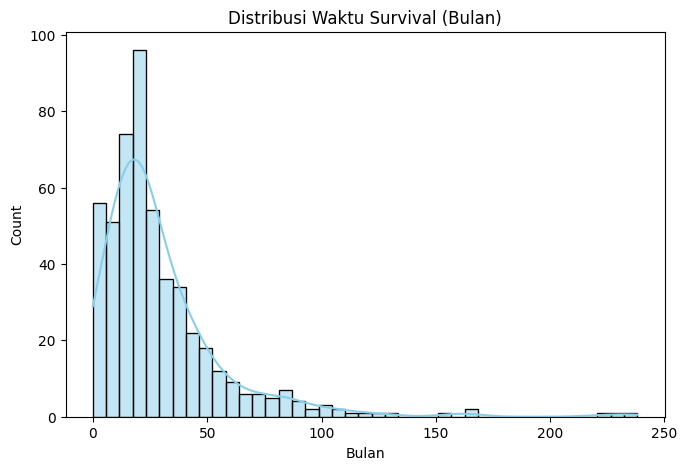

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(17, 5))

# Distribusi Waktu Survival
plt.subplot(1, 2, 1)
sns.histplot(df_clean['time'], kde=True, color='skyblue')
plt.title('Distribusi Waktu Survival (Bulan)')
plt.xlabel('Bulan')

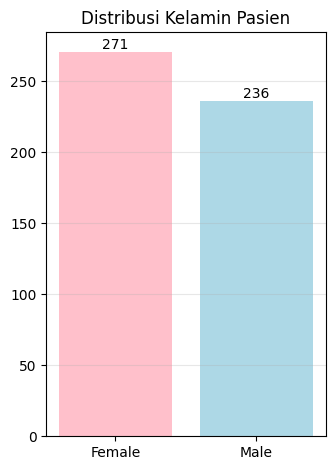

In [45]:
# Distribusi Kelamin
plt.subplot(1, 2, 2)
sex_counts = df_clean['sex'].value_counts().sort_index()
bars = plt.bar(['Female', 'Male'], sex_counts.values, color=['pink', 'lightblue'])
plt.title('Distribusi Kelamin Pasien')
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bars, labels=sex_counts.values)
plt.tight_layout()  
plt.show()

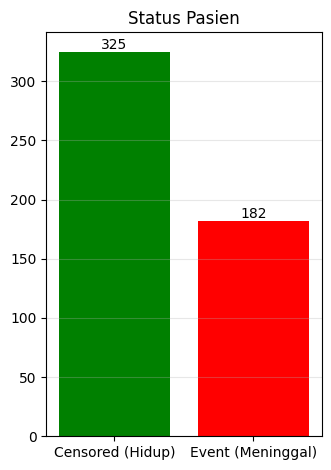

In [43]:
# Distribusi Kejadian (Hidup vs Meninggal)
plt.subplot(1, 2, 2)
event_counts = df_clean['event'].value_counts()
bars = plt.bar(['Censored (Hidup)', 'Event (Meninggal)'], event_counts.values, color=['green', 'red'])
plt.title('Status Pasien')
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bars, labels=event_counts.values)
plt.tight_layout()
plt.show()

C:\Users\ardia\AppData\Local\Temp\ipykernel_8460\649868031.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='stage', data=df_clean, palette='viridis')


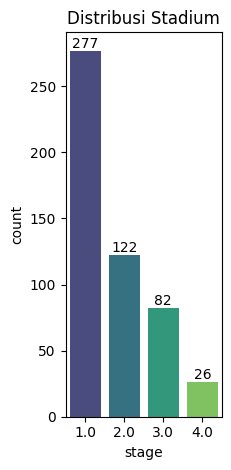

In [ ]:
plt.subplot(1, 3, 3)
ax = sns.countplot(x='stage', data=df_clean, palette='viridis')
plt.title('Distribusi Stadium')

for p in ax.patches:
    count = int(p.get_height())  # nilai count
    ax.text(p.get_x() + p.get_width()/2.,  
            p.get_height() + 0.05,          
            count,                          
            ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Kaplan Meier

In [48]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

## Kaplan Meier pada Stage

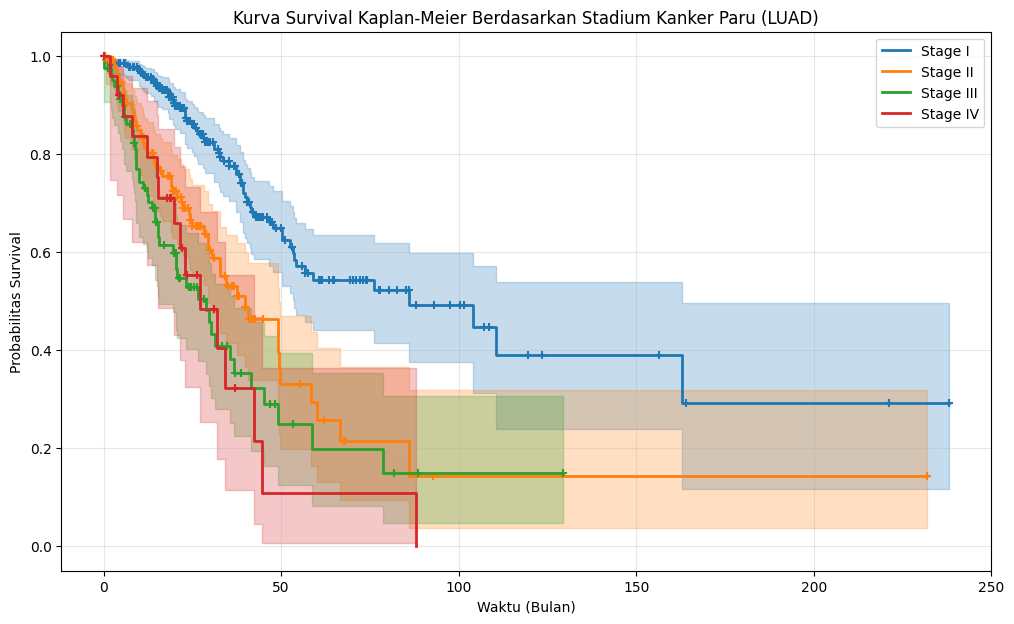

In [51]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(12, 7))

# Dictionary untuk label 
stage_labels = {1: 'Stage I', 2: 'Stage II', 3: 'Stage III', 4: 'Stage IV'}

# Loop melalui setiap stadium unik (1, 2, 3, 4) yang diurutkan
for stage_val in sorted(df_clean['stage'].unique()):
    # Filter data hanya untuk stadium tersebut
    mask = df_clean['stage'] == stage_val
    
    # Jika data ada, lakukan fitting
    if mask.sum() > 0:
        label_text = stage_labels.get(stage_val, f'Stage {stage_val}')
        kmf.fit(df_clean.loc[mask, 'time'], df_clean.loc[mask, 'event'], label=label_text)
        
        # Plot tanpa Confidence Interval (ci_show=False) 
        # Jika ingin melihat interval kepercayaan, ubah jadi True
        kmf.plot_survival_function(
            ci_show=True, 
            linewidth=2,
            show_censors=True, 
            censor_styles={'marker': '+', 'ms': 6, 'mew': 1.5})

plt.title('Kurva Survival Kaplan-Meier Berdasarkan Stadium Kanker Paru (LUAD)')
plt.ylabel('Probabilitas Survival')
plt.xlabel('Waktu (Bulan)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- SUMMARY UJI LOG-RANK (MULTIVARIATE) ---
print("\n[HASIL UJI LOG-RANK MULTIVARIAT]")
result = multivariate_logrank_test(
    event_durations=df_clean['time'], 
    groups=df_clean['stage'], 
    event_observed=df_clean['event']
)

# Menampilkan Summary Statistik
print(result.summary)

print(f"\nKesimpulan Statistik (p-value = {result.p_value:.10f}):")
if result.p_value < 0.05:
    print(">> TOLAK H0: Terdapat perbedaan signifikan pada kurva survival antar stadium.")
else:
    print(">> GAGAL TOLAK H0: Tidak cukup bukti untuk menyatakan kurva survival berbeda antar stadium.")



[HASIL UJI LOG-RANK MULTIVARIAT]
   test_statistic             p   -log2(p)
0       61.850324  2.365062e-13  41.943187

Kesimpulan Statistik (p-value = 0.0000000000):
>> TOLAK H0: Terdapat perbedaan signifikan pada kurva survival antar stadium.


## Kaplan Meier pada Gender

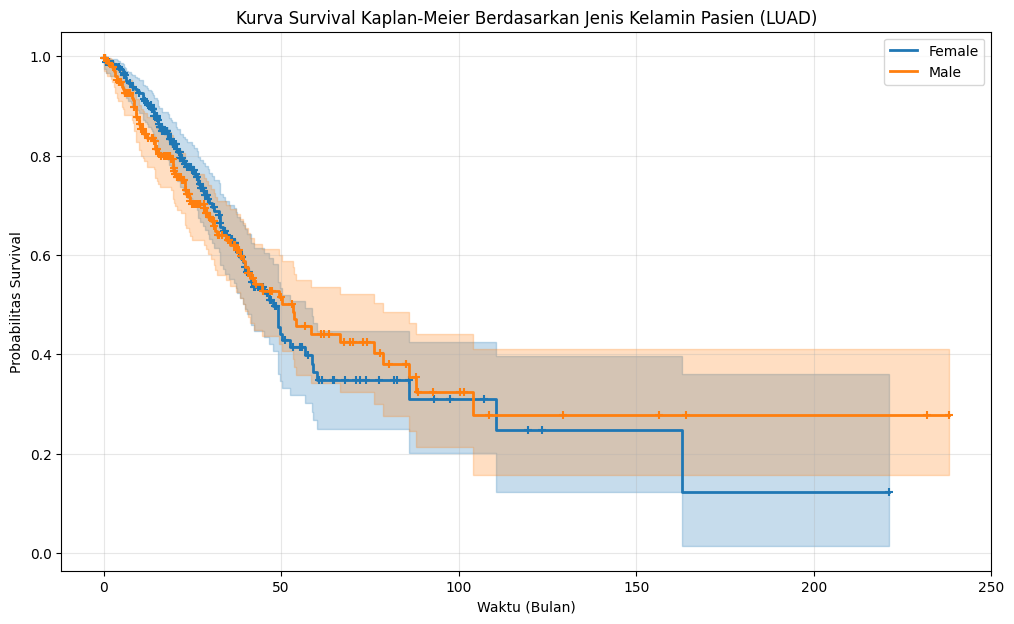

In [52]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(12, 7))

# Dictionary untuk label 
stage_labels = {1: 'Male', 0: 'Female'}

# Loop melalui setiap stadium unik (1, 2, 3, 4) yang diurutkan
for stage_val in sorted(df_clean['sex'].unique()):
    # Filter data hanya untuk stadium tersebut
    mask = df_clean['sex'] == stage_val
    
    # Jika data ada, lakukan fitting
    if mask.sum() > 0:
        label_text = stage_labels.get(stage_val, f'Stage {stage_val}')
        kmf.fit(df_clean.loc[mask, 'time'], df_clean.loc[mask, 'event'], label=label_text)
        
        # Plot tanpa Confidence Interval (ci_show=False)
        # Jika ingin melihat interval kepercayaan, ubah jadi True
        kmf.plot_survival_function(
            ci_show=True, 
            linewidth=2,
            show_censors=True, 
            censor_styles={'marker': '+', 'ms': 6, 'mew': 1.5})

plt.title('Kurva Survival Kaplan-Meier Berdasarkan Jenis Kelamin Pasien (LUAD)')
plt.ylabel('Probabilitas Survival')
plt.xlabel('Waktu (Bulan)')
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
# --- SUMMARY UJI LOG-RANK (MULTIVARIATE) ---
print("\n[HASIL UJI LOG-RANK MULTIVARIAT]")
result = multivariate_logrank_test(
    event_durations=df_clean['time'], 
    groups=df_clean['sex'], 
    event_observed=df_clean['event']
)

# Menampilkan Summary Statistik
print(result.summary)

print(f"\nKesimpulan Statistik (p-value = {result.p_value:.10f}):")
if result.p_value < 0.05:
    print(">> TOLAK H0: Terdapat perbedaan signifikan pada kurva survival antar jenis kelamin.")
else:
    print(">> GAGAL TOLAK H0: Tidak cukup bukti untuk menyatakan kurva survival berbeda antar jenis kelamin.")


[HASIL UJI LOG-RANK MULTIVARIAT]
   test_statistic         p  -log2(p)
0        0.054274  0.815786  0.293737

Kesimpulan Statistik (p-value = 0.8157860153):
>> GAGAL TOLAK H0: Tidak cukup bukti untuk menyatakan kurva survival berbeda antar jenis kelamin.


# Regresi Cox